<!-- # Chat Link
Confirm this was acceptable: [link](https://t3.chat/share/ldlkpvnpwq) -->
# Imports

In [28]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, multilabel_confusion_matrix
from nltk.stem import WordNetLemmatizer, PorterStemmer
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multioutput import MultiOutputClassifier
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from nltk.corpus import stopwords

In [14]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /home/allan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/allan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/allan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/allan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Preprocessing

In [3]:
# df = pd.read_csv("../data.csv")
df = pd.read_csv("../updated.csv")
df.head()

,doc_id,text,category_1,category_2,sentiment
0,1,Trump's presidency has been tattered with scan...,1,none,Negative
1,2,My machine learning course has been really enj...,2,none,Positive
2,3,The plot of the final season of The Boys has b...,3,none,Negative
3,4,I enjoy getting learning about strength traini...,4,none,Positive
4,5,It's concerning our government is partnering w...,1,2,Negative


In [4]:
df.fillna({"category_2": "none"}, inplace=True)

,doc_id,text,category_1,category_2,sentiment
0,1,Trump's presidency has been tattered with scan...,1,none,Negative
1,2,My machine learning course has been really enj...,2,none,Positive
2,3,The plot of the final season of The Boys has b...,3,none,Negative
3,4,I enjoy getting learning about strength traini...,4,none,Positive
4,5,It's concerning our government is partnering w...,1,2,Negative
...,...,...,...,...,...
805,806,Their efforts to debug the code for their proj...,1,2,neutral
806,807,The girl used her knowledge in data science to...,2,3,positive
807,808,The greedy filmaker wanted his television situ...,3,4,negative
808,809,The couple sought out counseling with the ther...,4,5,negative


In [5]:
df = df[~df["sentiment"].isnull()]

In [6]:
df["sentiment"].value_counts()

sentiment
Positive     226
Negative     209
Neutral      196
negative      52
positive      52
neutral       50
positive       4
Nuetral        2
Postive        2
Neutral        2
Neutral.       1
Positve        1
Netural        1
neutral        1
Name: count, dtype: int64

# TODO
clean sentiment

# Helpers

In [7]:
df["category_2"] = df["category_2"].str.strip()

In [8]:
df['all_categories'] = df[['category_1', 'category_2']].values.tolist()

def clean_labels(label_list):
    cleaned = [str(i) for i in label_list if str(i).lower() != 'none' and i is not None]
    return cleaned

df['all_categories'] = df['all_categories'].apply(clean_labels)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['all_categories'])

In [11]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
nltk_stops = set(stopwords.words('english'))

def s_token(doc):
   return [stemmer.stem(w) for w in nltk.word_tokenize(doc)]

def l_token(doc):
   return [lemmatizer.lemmatize(w) for w in nltk.word_tokenize(doc)]

In [12]:
vecs = {"bow": CountVectorizer, "tfidf": TfidfVectorizer}
models = {"log_reg": LogisticRegression, "mnb": MultinomialNB, "svc": SVC}
stops = {"no": None, "yes": "english"} # means remove stops
ngrams = [i for i in range(1, 5)]
tokenizers = {"none": None, "stem": s_token, "lemma": l_token}

# Grid Search

In [15]:
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(msss.split(df["text"], y))

X_train_raw, X_test_raw = df["text"].iloc[train_idx], df["text"].iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

results = []

for vec_name, vec_class in vecs.items():
    for stop_name, stop_val in stops.items():
        for n in ngrams:
            for tokenizer_name, tokenizer in tokenizers.items():
                if stop_name == "yes":
                    if tokenizer_name == "none":
                        current_stops = list(nltk_stops)
                    else:
                        tokenized_stops = []
                        for word in nltk_stops:
                            tokenized_stops.extend(nltk.word_tokenize(word))
                        
                        if tokenizer_name == "lemma":
                            current_stops = [lemmatizer.lemmatize(w) for w in tokenized_stops]
                        else:
                            current_stops = [stemmer.stem(w) for w in tokenized_stops]
                            
                        current_stops = list(set(current_stops))
                else:
                    current_stops = None            
                
                if tokenizer == None:
                    vectorizer = vec_class(stop_words=current_stops, ngram_range=(1, n))
                else:
                    vectorizer = vec_class(
                        stop_words=current_stops, 
                        ngram_range=(1, n), 
                        token_pattern=None, 
                        tokenizer=tokenizer
                    )

                X_train_vec = vectorizer.fit_transform(X_train_raw)
                X_test_vec = vectorizer.transform(X_test_raw)
                
                for model_name, model_class in models.items():
                    if model_name == "mnb":
                        base_model = model_class()
                    else:
                        base_model = model_class(random_state=42)
                    
                    multi_model = MultiOutputClassifier(base_model)
                    multi_model.fit(X_train_vec, y_train)
                    
                    preds = multi_model.predict(X_test_vec)
                    score = f1_score(y_test, preds, average='macro') 
                    
                    results.append({
                        "model": model_name,
                        "vectorizer": vec_name,
                        "tokenizer": tokenizer_name,
                        "stop_words": stop_name,
                        "ngram_max": n,
                        "f1_score": score
                    })

res_df = pd.DataFrame(results)

/home/allan/workspace/cs105_final_project/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['becau'] not in stop_words.
  warnings.warn(
/home/allan/workspace/cs105_final_project/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['becau'] not in stop_words.
  warnings.warn(
/home/allan/workspace/cs105_final_project/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['becau'] not in stop_words.
  warnings.warn(
/home/allan/workspace/cs105_final_project/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsi

# Explore

In [16]:
res_df.head()

,model,vectorizer,tokenizer,stop_words,ngram_max,f1_score
0,log_reg,bow,none,no,1,0.811481
1,mnb,bow,none,no,1,0.872165
2,svc,bow,none,no,1,0.585539
3,log_reg,bow,stem,no,1,0.835943
4,mnb,bow,stem,no,1,0.880055


In [17]:
res_df[res_df["f1_score"] == res_df["f1_score"].max()]

,model,vectorizer,tokenizer,stop_words,ngram_max,f1_score
40,mnb,bow,stem,yes,1,0.891319


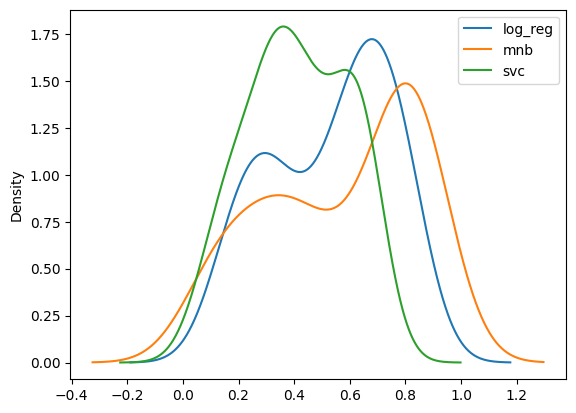

In [18]:
res_df.groupby("model")["f1_score"].plot(kind="kde", legend=True)
plt.show()

In [19]:
res_df.groupby("model")["f1_score"].median()

model
log_reg    0.590837
mnb        0.651726
svc        0.407577
Name: f1_score, dtype: float64

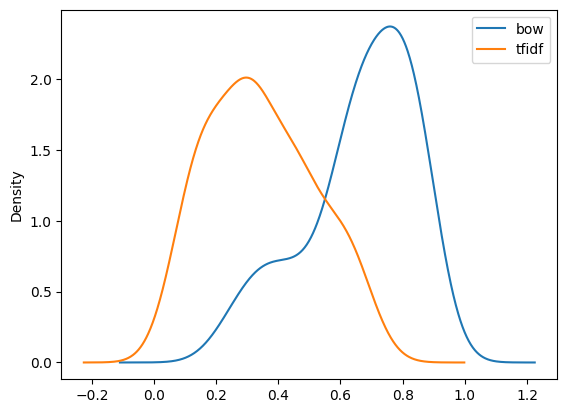

In [20]:
res_df.groupby("vectorizer")["f1_score"].plot(kind="kde", legend=True)
plt.show()

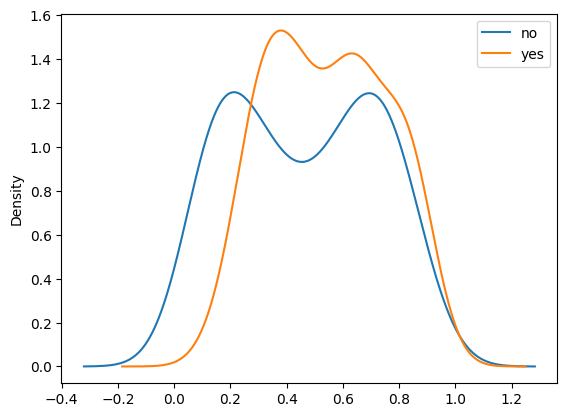

In [21]:
res_df.groupby("stop_words")["f1_score"].plot(kind="kde", legend=True)
plt.show()

In [22]:
res_df.groupby("stop_words")["f1_score"].median()

stop_words
no     0.466504
yes    0.555406
Name: f1_score, dtype: float64

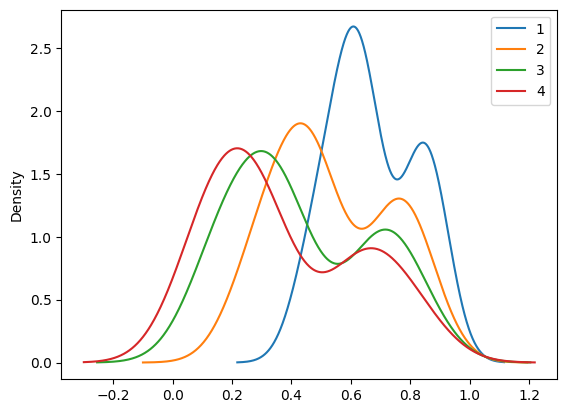

In [23]:
res_df.groupby("ngram_max")["f1_score"].plot(kind="kde", legend=True)
plt.show()

In [24]:
res_df.groupby("ngram_max")["f1_score"].median()

ngram_max
1    0.649647
2    0.471821
3    0.347120
4    0.278850
Name: f1_score, dtype: float64

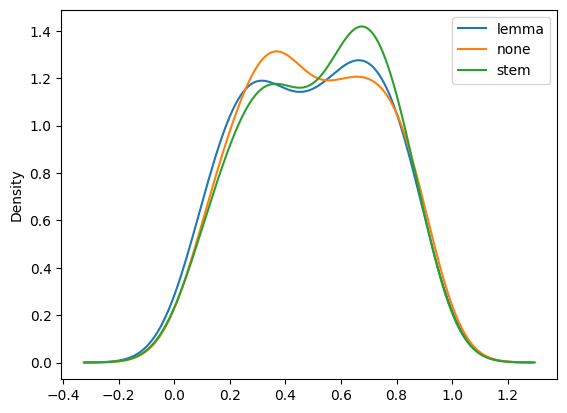

In [25]:
res_df.groupby("tokenizer")["f1_score"].plot(kind="kde", legend=True)
plt.show()

In [26]:
res_df.groupby("tokenizer")["f1_score"].median()

tokenizer
lemma    0.503049
none     0.485836
stem     0.541228
Name: f1_score, dtype: float64

# Findings
I need to run statistical tests to say this with more certainty but tentatively, it appears using BOW and 1 ngram made the most difference followed by Naive bayes and removing stop words. Different tokenizers did not seem to make much of an impact.

# TODO
- OHE i think Countvetorizer(binary=True)
- Add KNN to gridsearch
- Run a test
- Try other visual like confusion matrix for best model

# Best Model

In [29]:
# mnb	bow	stem	yes	1	0.891319
tokenized_stops = []
for word in nltk_stops:
    tokenized_stops.extend(nltk.word_tokenize(word))
current_stops = [stemmer.stem(w) for w in tokenized_stops]
current_stops = list(set(current_stops))

vectorizer = CountVectorizer(
    stop_words=current_stops, 
    ngram_range=(1, n), 
    token_pattern=None, 
    tokenizer=tokenizer
)

X_train_vec = vectorizer.fit_transform(X_train_raw)
X_test_vec = vectorizer.transform(X_test_raw)

base_model = MultinomialNB()
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train_vec, y_train)

preds = multi_model.predict(X_test_vec)

multilabel_confusion_matrix(y_test, preds)

array([[[108,   2],
        [ 10,  35]],

       [[107,   0],
        [ 14,  34]],

       [[107,   0],
        [ 19,  29]],

       [[104,   4],
        [ 14,  33]],

       [[104,   1],
        [ 14,  36]]])